In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

#### Task: Read diabetes_dirty.csv into your Jupyter notebook

In [3]:
# Load the data
data = pd.read_csv("diabetes_dirty.csv")
data.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,PROGRESSION
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


#### Task: Differentiate between the independent variables and the dependent variable, and assign them to variables X and Y.

AGE (Age in years)
SEX (1 for female, 2 for male)
BMI (Body mass index)
BP (Average blood pressure)
S1 (Total serum cholesterol)
S2 (Low-density lipoproteins)
S3 (High-density lipoproteins)
S4 (Total cholesterol / HDL)
S5 (Possibly log of serum triglycerides level)
S6 (Blood sugar level)

In [5]:
# Explore the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE          442 non-null    int64  
 1   SEX          442 non-null    int64  
 2   BMI          442 non-null    float64
 3   BP           442 non-null    float64
 4   S1           442 non-null    int64  
 5   S2           442 non-null    float64
 6   S3           442 non-null    float64
 7   S4           442 non-null    float64
 8   S5           442 non-null    float64
 9   S6           442 non-null    int64  
 10  PROGRESSION  442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [7]:
# Explore the data
data.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,PROGRESSION
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


### Dependent Variable (Y):
This is the variable you are trying to predict or explain. From the list you provided, I will choose (PROGRESSION) seems like the most likely candidate for the dependent variable.

Thus, Y = PROGRESSION.

### Independent Variables (X):
These are the variables that might influence or predict the dependent variable. Based on your list, the independent variables would likely be:

AGE (Age in years)
SEX (1 for female, 2 for male)
BMI (Body Mass Index)
BP (Average blood pressure)
S1 (Total serum cholesterol)
S2 (Low-density lipoproteins)
S3 (High-density lipoproteins)
S4 (Total cholesterol / HDL)
S5 (Possibly log of serum triglycerides level)
S6 (Blood sugar level)

### To summarize:

Y = PROGRESSION
X = [AGE, SEX, BMI, BP, S1, S2, S3, S4, S5, S6] (independent variables)

### Age Simple Linear Model

In [11]:
# Select and reshape data
x = data.iloc[:,0].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

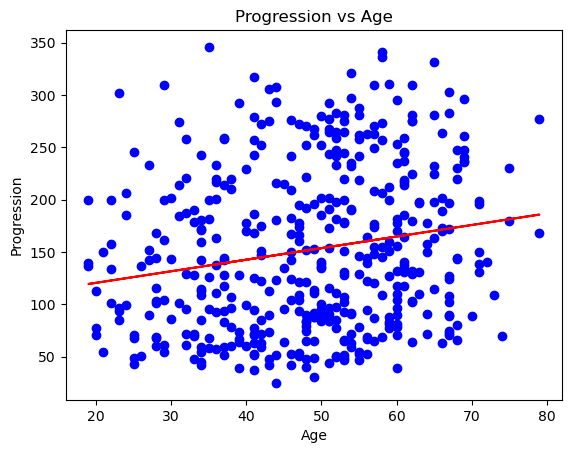

In [13]:
# Create an empty linear regression model
age = LinearRegression()

# Create the model using fit(x,y)
age.fit(x,y)

# Use model to make a prediction
y_pred = age.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,age.predict(x),color = 'r')
plt.title('Progression vs Age')
plt.xlabel('Age')
plt.ylabel('Progression')
plt.show()

In [15]:
# Age model coefficients
print('Coefficients: \n', age.coef_)

Coefficients: 
 [[1.10495671]]


### Average blood pressure Simple Linear Model

In [17]:
# Select and reshape data
x = data.iloc[:,3].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

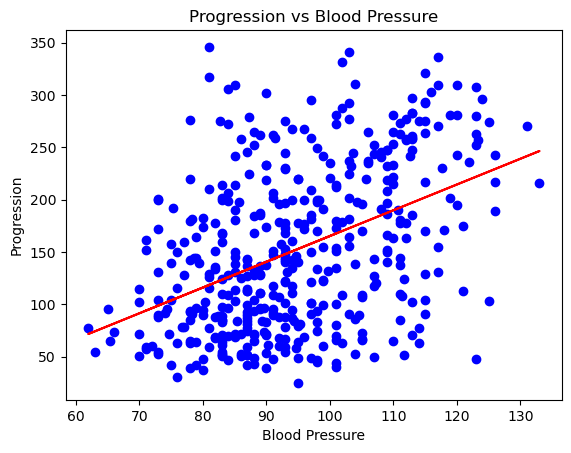

In [19]:
# Create an empty linear regression model
blood_pressure = LinearRegression()

# Create the model using fit(x,y)
blood_pressure.fit(x,y)

# Use model to make a prediction
y_pred = blood_pressure.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,blood_pressure.predict(x),color = 'r')
plt.title('Progression vs Blood Pressure')
plt.xlabel('Blood Pressure')
plt.ylabel('Progression')
plt.show()

In [21]:
# Blood Pressure model coefficients
print('Coefficients: \n', blood_pressure.coef_)

Coefficients: 
 [[2.46073731]]


### Total serum cholesterol Simple Linear Model (S1)

In [23]:
# Select and reshape data
x = data.iloc[:,4].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

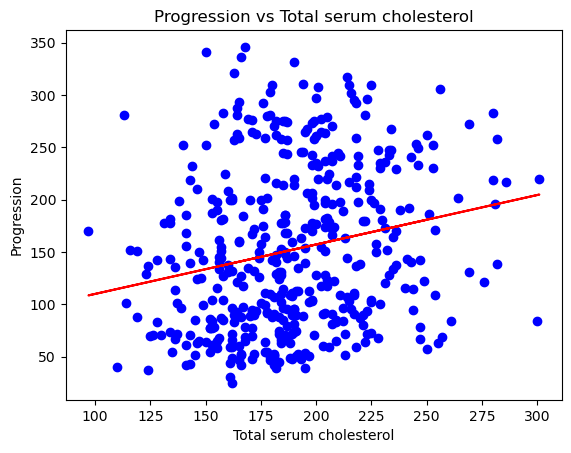

In [25]:
# Create an empty linear regression model
s1 = LinearRegression()

# Create the model using fit(x,y)
s1.fit(x,y)

# Use model to make a prediction
y_pred = s1.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s1.predict(x),color = 'r')
plt.title('Progression vs Total serum cholesterol')
plt.xlabel('Total serum cholesterol')
plt.ylabel('Progression')
plt.show()

### Low-density lipoproteins Simple Linear Model (S2)

In [27]:
# Select and reshape data
x = data.iloc[:,5].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

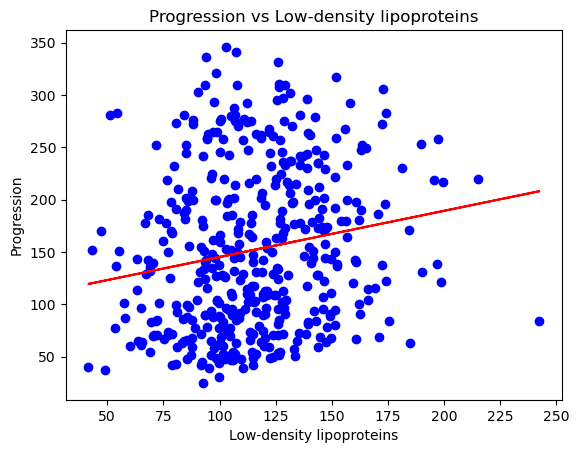

In [29]:
# Create an empty linear regression model
s2 = LinearRegression()

# Create the model using fit(x,y)
s2.fit(x,y)

# Use model to make a prediction
y_pred = s2.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s2.predict(x),color = 'r')
plt.title('Progression vs Low-density lipoproteins')
plt.xlabel('Low-density lipoproteins')
plt.ylabel('Progression')
plt.show()

### High-density lipoproteins Simple Linear Model (S3)

In [48]:
# Select and reshape data
x = data.iloc[:,6].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

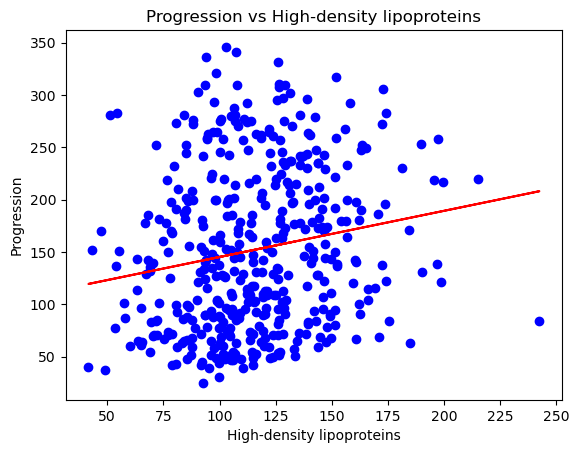

In [31]:
# Create an empty linear regression model
s3 = LinearRegression()

# Create the model using fit(x,y)
s3.fit(x,y)

# Use model to make a prediction
y_pred = s3.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s3.predict(x),color = 'r')
plt.title('Progression vs High-density lipoproteins')
plt.xlabel('High-density lipoproteins')
plt.ylabel('Progression')
plt.show()

### Total cholesterol / HDL Simple Linear Model (S4)

In [33]:
# Select and reshape data
x = data.iloc[:,7].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

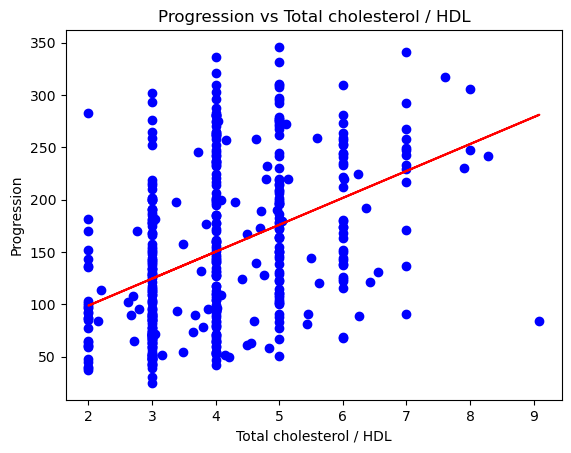

In [35]:
# Create an empty linear regression model
s4 = LinearRegression()

# Create the model using fit(x,y)
s4.fit(x,y)

# Use model to make a prediction
y_pred = s4.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s4.predict(x),color = 'r')
plt.title('Progression vs Total cholesterol / HDL')
plt.xlabel('Total cholesterol / HDL')
plt.ylabel('Progression')
plt.show()

### Possibly log of serum triglycerides level Simple Linear Model (S5)

In [37]:
# Select and reshape data
x = data.iloc[:,8].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

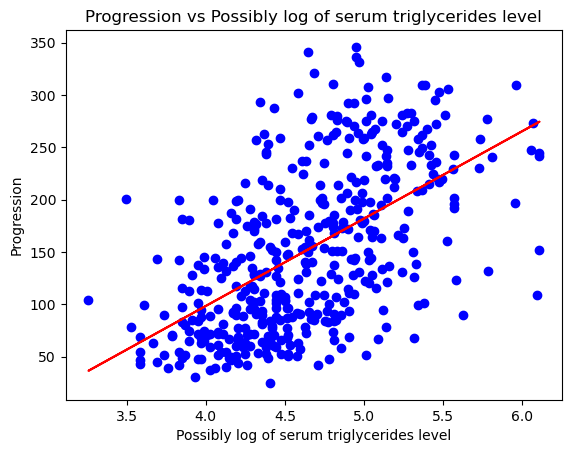

In [39]:
# Create an empty linear regression model
s5 = LinearRegression()

# Create the model using fit(x,y)
s5.fit(x,y)

# Use model to make a prediction
y_pred = s5.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s5.predict(x),color = 'r')
plt.title('Progression vs Possibly log of serum triglycerides level')
plt.xlabel('Possibly log of serum triglycerides level')
plt.ylabel('Progression')
plt.show()

### Blood sugar level Simple Linear Model (S6)

In [41]:
# Select and reshape data
x = data.iloc[:,9].values
y = data.iloc[:,10].values
y=y.reshape(-1, 1)
x=x.reshape(-1, 1)

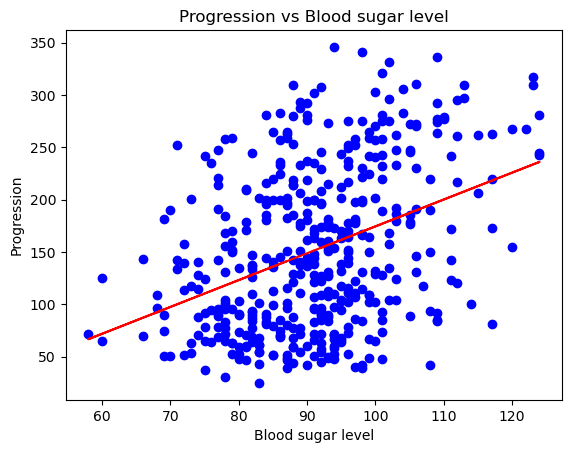

In [43]:
# Create an empty linear regression model
s6 = LinearRegression()

# Create the model using fit(x,y)
s6.fit(x,y)

# Use model to make a prediction
y_pred = s6.predict(x)

# Plot model and data
plt.scatter(x,y,color = 'b')
plt.plot(x,s6.predict(x),color = 'r')
plt.title('Progression vs Blood sugar level')
plt.xlabel('Blood sugar level')
plt.ylabel('Progression')
plt.show()

#### Task: Generate training and test sets comprising 80% and 20% of the data respectively.

### Training and test samples

In [53]:
# Select and reshape data
X_columns = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Y = data.iloc[:,10].values
Y = Y.reshape(-1, 1)
X = data.iloc[:, X_columns].values
X = X.reshape(-1, len(X_columns))

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=23)

print("Training data:",X_train.shape, y_train.shape)
print("Test data:",X_test.shape, y_test.shape)

Training data: (353, 10) (353, 1)
Test data: (89, 10) (89, 1)


#### Task: Investigate the necessity for scaling or normalisation of the data. Employ MinMaxScaler and StandardScaler if necessary. Fit these scalers on the training set and apply the fitted scalers to transform both the training and test sets accordingly.

#### And

#### Task: Generate a multiple linear regression model using the training set. Use all of the independent variables.

### Multiple Linear Regression

In [57]:
print(data.columns)

Index(['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6',
       'PROGRESSION'],
      dtype='object')


In [59]:
# Select features (independent variables) for multivariate regression
X = data.iloc[:,[0, 2, 3, 4, 5, 6, 7, 8, 9]].values # Using AGE, BMI, BP, S1, S2, S3, S4, S5, S6 as features
X[1:10] # Display a few rows of the feature matrix

array([[ 48.    ,  21.6   ,  87.    , 183.    , 103.2   ,  70.    ,
          3.    ,   3.8918,  69.    ],
       [ 72.    ,  30.5   ,  93.    , 156.    ,  93.6   ,  41.    ,
          4.    ,   4.6728,  85.    ],
       [ 24.    ,  25.3   ,  84.    , 198.    , 131.4   ,  40.    ,
          5.    ,   4.8903,  89.    ],
       [ 50.    ,  23.    , 101.    , 192.    , 125.4   ,  52.    ,
          4.    ,   4.2905,  80.    ],
       [ 23.    ,  22.6   ,  89.    , 139.    ,  64.8   ,  61.    ,
          2.    ,   4.1897,  68.    ],
       [ 36.    ,  22.    ,  90.    , 160.    ,  99.6   ,  50.    ,
          3.    ,   3.9512,  82.    ],
       [ 66.    ,  26.2   , 114.    , 255.    , 185.    ,  56.    ,
          4.55  ,   4.2485,  92.    ],
       [ 60.    ,  32.1   ,  83.    , 179.    , 119.4   ,  42.    ,
          4.    ,   4.4773,  94.    ],
       [ 29.    ,  30.    ,  85.    , 180.    ,  93.4   ,  43.    ,
          4.    ,   5.3845,  88.    ]])

In [90]:
# Select and reshape the target variable PROGRESSION
y = data.iloc[:,10].values
y = y.reshape(-1, 1)
X = X.reshape(-1, X.shape[1]) # Reshape X to a 2D array

#### Multivariate Linear Regression (with feature scaling)


In [92]:
# Create an empty linear regression model
diabetes_model = LinearRegression()

# Create the model using fit(X,y)
diabetes_model.fit(X,y)

# Get intercept and coefficients
print('Intercept: \n', diabetes_model.intercept_)
print('Coefficients: \n', diabetes_model.coef_)

Intercept: 
 [-363.89871603]
Coefficients: 
 [[-0.12051511  6.00406612  0.95050794 -0.98078427  0.65849619  0.51362821
   4.65988116 68.9473421   0.2026253 ]]


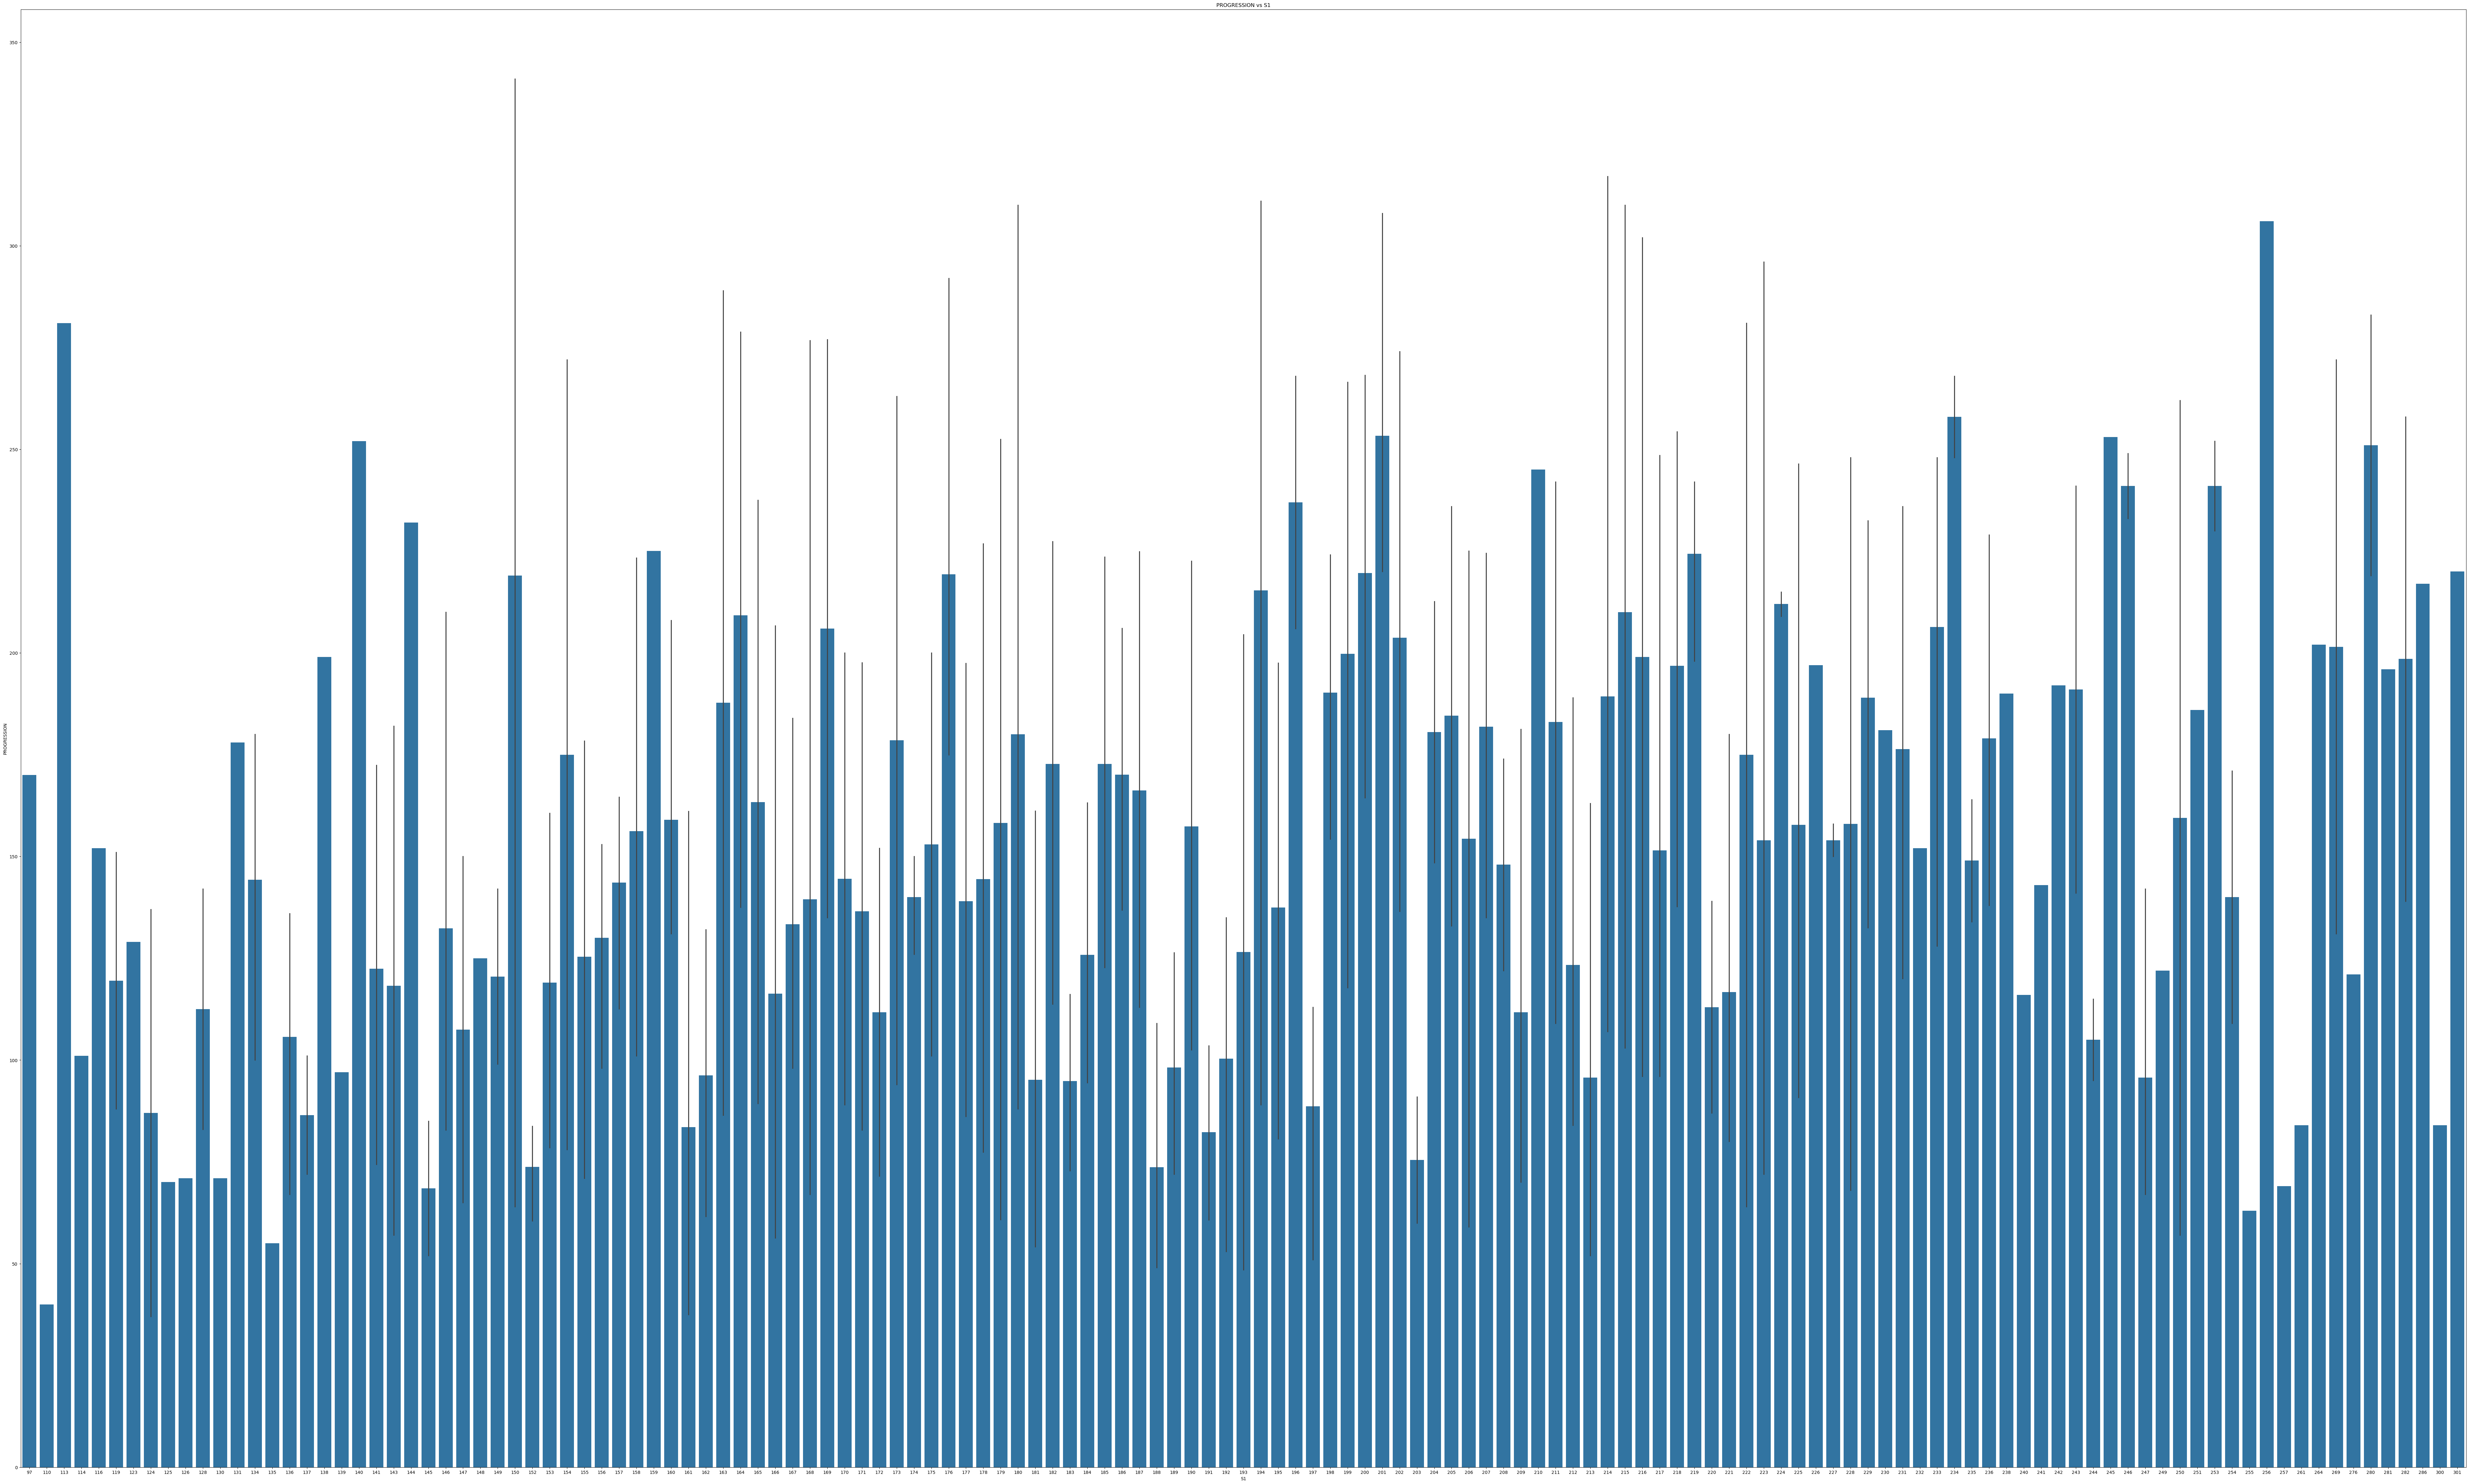

In [67]:
# Example: Visualization (PROGRESSION vs. S1)
# Create a bar plot to visualize the results
plt.figure(figsize=(100, 60))  # Adjust figure size as needed
sns.barplot(x='S1', y='PROGRESSION', data=data) # Using seaborn's barplot

# Customize the plot
plt.title('PROGRESSION vs S1')
plt.xlabel('S1')
plt.ylabel('PROGRESSION')

# Show the plot
plt.show()

Looks like the features don't follow a Gaussian distribution. Let's normalise our data using MinMaxScaler.

Fitting these scalers on the training set and applying the fitted scalers to transform both the training and test sets accordingly.

#### Feature Scaling (MinMaxScaler)

In [69]:
# Initialize the MinMaxScaler
sc = MinMaxScaler()
# Fit the scaler on training data
sc.fit(X_train)

# Apply the scaler on training and test data
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

#### Multivariate Linear Regression (with scaled features)

#### Fit the model on the training data

In [71]:
# Fit a model
lm = LinearRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)

#### Task: Print out the intercept and coefficients of the trained model.

In [73]:
print('Intercept: \n', lm.intercept_)
print('Coefficients: \n', lm.coef_)

Intercept: 
 [0.2631382]
Coefficients: 
 [[  -4.325416    -25.87489936  130.23755571   79.72225993 -281.78073485
   169.4272368    62.57500688   61.16459841  195.21322347   20.61117695]]


#### Task: Generate predictions for the test set.

In [75]:
# Predictions
predictions[0:10]

array([[290.8985031 ],
       [132.81832981],
       [140.44601181],
       [ 30.52576133],
       [200.92486072],
       [198.95481117],
       [196.91371478],
       [147.93181701],
       [213.17880041],
       [212.11885067]])

#### Task: Compute R squared for your model on the test set. You can use r2_score from sklearn.metrics to obtain this score.

In [77]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)

# Print the R² score
print(f"R² score: {r2}")

R² score: 0.4588389962630466


R-squared (R²):
R² measures how well a regression model fits observed data, ranging from 0 (no fit) to 1 (perfect fit). The 0.4588 score means the model explains about 46% of the target variable's variance. This suggests a moderate fit, leaving room for improvement. It necessary considerate feature engineering, trying different models, or tuning hyperparameters. R² alone isn't a complete picture in the case.  
Context matters: a 0.46 R² might be good in some fields, less so in others.